# Genomics of Drug Sensitivity in Cancer (GDSC) — Analysis Notebook

In [42]:
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter as tk
import pandas as pd
import numpy as np
import math

In [2]:
def get_screen_size():
    # Get screen size
    root = tk.Tk()
    screen_width = root.winfo_screenwidth()
    screen_height = root.winfo_screenheight()
    root.destroy()

    # Calculate figure size (e.g., 70% of screen)
    dpi = 100
    fig_width = (screen_width * 0.7) / dpi
    fig_height = (screen_height * 0.7) / dpi

    return fig_width, fig_height

SCREEN_W, SCREEN_H = get_screen_size()
TARGET = "TARGET"

## 1. Data Loading

In [3]:
gdsc = pd.read_excel("../data/GDSC.xlsx")

## 2. Initial Dataset Inspection

In [4]:
gdsc.head()

,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,687448,COLO-829,SKCM,1003,Camptothecin,-1.235034,0.867348,0.557727,skin,melanoma,SKCM,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,687455,RT4,BLCA,1003,Camptothecin,-2.963191,0.821438,-0.383200,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
3,687457,SW780,BLCA,1003,Camptothecin,-1.449138,0.905050,0.441154,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication
4,687459,TCCSUP,BLCA,1003,Camptothecin,-2.350633,0.843430,-0.049682,urogenital_system,Bladder,BLCA,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,TOP1,DNA replication


In [5]:
gdsc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162103 entries, 0 to 162102
Data columns (total 19 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   COSMIC_ID                                162103 non-null  int64  
 1   CELL_LINE_NAME                           162103 non-null  object 
 2   TCGA_DESC                                162103 non-null  object 
 3   DRUG_ID                                  162103 non-null  int64  
 4   DRUG_NAME                                162103 non-null  object 
 5   LN_IC50                                  162103 non-null  float64
 6   AUC                                      162103 non-null  float64
 7   Z_SCORE                                  162103 non-null  float64
 8   GDSC Tissue descriptor 1                 162103 non-null  object 
 9   GDSC Tissue descriptor 2                 162103 non-null  object 
 10  Cancer Type (matching TCGA label

In [6]:
gdsc.nunique()

COSMIC_ID                                     737
CELL_LINE_NAME                                737
TCGA_DESC                                      30
DRUG_ID                                       254
DRUG_NAME                                     246
LN_IC50                                    159646
AUC                                        109624
Z_SCORE                                    158203
GDSC Tissue descriptor 1                       17
GDSC Tissue descriptor 2                       33
Cancer Type (matching TCGA label)              30
Microsatellite instability Status (MSI)         2
Screen Medium                                   2
Growth Properties                               3
CNA                                             2
Gene Expression                                 2
Methylation                                     2
TARGET                                        183
TARGET_PATHWAY                                 23
dtype: int64

In [7]:
gdsc.describe()

,COSMIC_ID,DRUG_ID,LN_IC50,AUC,Z_SCORE
count,1.621030e+05,162103.000000,162103.000000,162103.000000,162103.000000
mean,9.857634e+05,1554.527603,2.822644,0.879924,0.037711
std,2.240213e+05,406.964712,2.836231,0.148592,0.999098
min,6.836670e+05,1003.000000,-8.642551,0.006282,-6.909716
25%,9.059780e+05,1086.000000,1.476170,0.845967,-0.615884
50%,9.092570e+05,1598.000000,3.271447,0.941467,0.048930
75%,1.240143e+06,1910.000000,4.767629,0.973917,0.686466
max,1.674021e+06,2499.000000,13.820189,0.998904,7.978776


## 3. Data Quality Assessment

In [8]:
# check for missing values
gdsc.isnull().sum()

COSMIC_ID                                  0
CELL_LINE_NAME                             0
TCGA_DESC                                  0
DRUG_ID                                    0
DRUG_NAME                                  0
LN_IC50                                    0
AUC                                        0
Z_SCORE                                    0
GDSC Tissue descriptor 1                   0
GDSC Tissue descriptor 2                   0
Cancer Type (matching TCGA label)          0
Microsatellite instability Status (MSI)    0
Screen Medium                              0
Growth Properties                          0
CNA                                        0
Gene Expression                            0
Methylation                                0
TARGET                                     0
TARGET_PATHWAY                             0
dtype: int64

In [9]:
# check for duplicates
gdsc.duplicated(subset=['CELL_LINE_NAME', 'DRUG_NAME']).sum()

np.int64(4290)

In [10]:
#Checking for variations in the other columns for the duplicate combinations
cols_to_check = [
    'Microsatellite instability Status (MSI)',
    'CNA',
    'Gene Expression',
    'Methylation',
    'Screen Medium',
    'Growth Properties',
    'TARGET',
    'TARGET_PATHWAY',
    'GDSC Tissue descriptor 1',
    'GDSC Tissue descriptor 2',
    'Cancer Type (matching TCGA label)'
]

gdsc.groupby(['COSMIC_ID', 'DRUG_NAME'])[cols_to_check].nunique().max()

Microsatellite instability Status (MSI)    1
CNA                                        1
Gene Expression                            1
Methylation                                1
Screen Medium                              1
Growth Properties                          1
TARGET                                     1
TARGET_PATHWAY                             1
GDSC Tissue descriptor 1                   1
GDSC Tissue descriptor 2                   1
Cancer Type (matching TCGA label)          1
dtype: int64

We observed that there are **737** unique **COSMIC_ID** and **246** unique **DRUG_NAME**. The possible combination of all DRUG_NAME and COMIC_ID of cell lines will give a total **181302** entries, but in our dataset we have have only **162103** entries. This mean that not all drug were tested on every cell line. We checked if all combination of cell line and drug name were unique and we found that there were 4290 duplicated combination of cell line and drug name. We went further to check if other features were unique for the duplicated observations. This led to the confirmation that they are actually duplicates rather than seperate experiments. Upon further investigations, we found out that there a possibility that data were collected from different experiments which vary owing  to the different sensitivity metrics. Therefore, rather than deleting the duplicates we've decided to keep them.

In [11]:
(gdsc['TCGA_DESC'] == gdsc['Cancer Type (matching TCGA label)']).all()

np.False_

In [12]:
gdsc[['TCGA_DESC', 'Cancer Type (matching TCGA label)']].head(100)

,TCGA_DESC,Cancer Type (matching TCGA label)
0,MB,MB
1,SKCM,SKCM
2,BLCA,BLCA
3,BLCA,BLCA
4,BLCA,BLCA
...,...,...
95,BLCA,BLCA
96,LUSC,LUSC
97,ESCA,ESCA
98,LUSC,LUSC


In [13]:
mask = gdsc['TCGA_DESC'] != gdsc['Cancer Type (matching TCGA label)']

gdsc.loc[mask, ['TCGA_DESC', 'Cancer Type (matching TCGA label)']]

,TCGA_DESC,Cancer Type (matching TCGA label)
145,COREAD,COAD/READ
146,COREAD,COAD/READ
148,COREAD,COAD/READ
168,COREAD,COAD/READ
169,COREAD,COAD/READ
...,...,...
162009,COREAD,COAD/READ
162099,COREAD,COAD/READ
162100,COREAD,COAD/READ
162101,COREAD,COAD/READ


# Exploratory Data Analysis

## Univariate Analysis

### Continuous Variables

In [14]:
def plot_distribution(data: pd.DataFrame = None, columns: list[str] = None):
    if data is None or columns is None:
        print("Missing dataframe or columns")
        return

    n = len(columns)
    n_cols = min(n, 3)
    n_rows = math.ceil(n / n_cols)

    figure = plt.figure(figsize=(SCREEN_W, SCREEN_H / n))
    outer_grid = GridSpec(n_rows, n_cols, wspace=.25, hspace=.35)
    
    for i, column in enumerate(columns):
        r, c = divmod(i, n_cols)
        
        inner_grid = GridSpecFromSubplotSpec(
            nrows=2, 
            ncols=1, 
            subplot_spec=outer_grid[r, c],
            height_ratios=[3, 1],
            hspace=.05
        )

        # --- Histogram
        hist_axe = figure.add_subplot(inner_grid[0])
        sns.histplot(data[column], bins=30, ax=hist_axe, color='skyblue')

        # Compute mean & median
        mean_val = data[column].mean()
        median_val = data[column].median()

        # Add vertical lines
        hist_axe.axvline(mean_val, color='blue', linestyle='--',
                         label=f'Mean: {mean_val:.2f}')
        hist_axe.axvline(median_val, color='red', linestyle='-',
                         label=f'Median: {median_val:.2f}')

        hist_axe.set_title(f"Distribution of {column}")
        hist_axe.set_xlabel("")
        hist_axe.legend()

        # --- Boxplot
        box_axe = figure.add_subplot(inner_grid[1])
        sns.boxplot(x=data[column].dropna(), ax=box_axe, color='skyblue')
        box_axe.set_xlabel(column)
        
    plt.show()

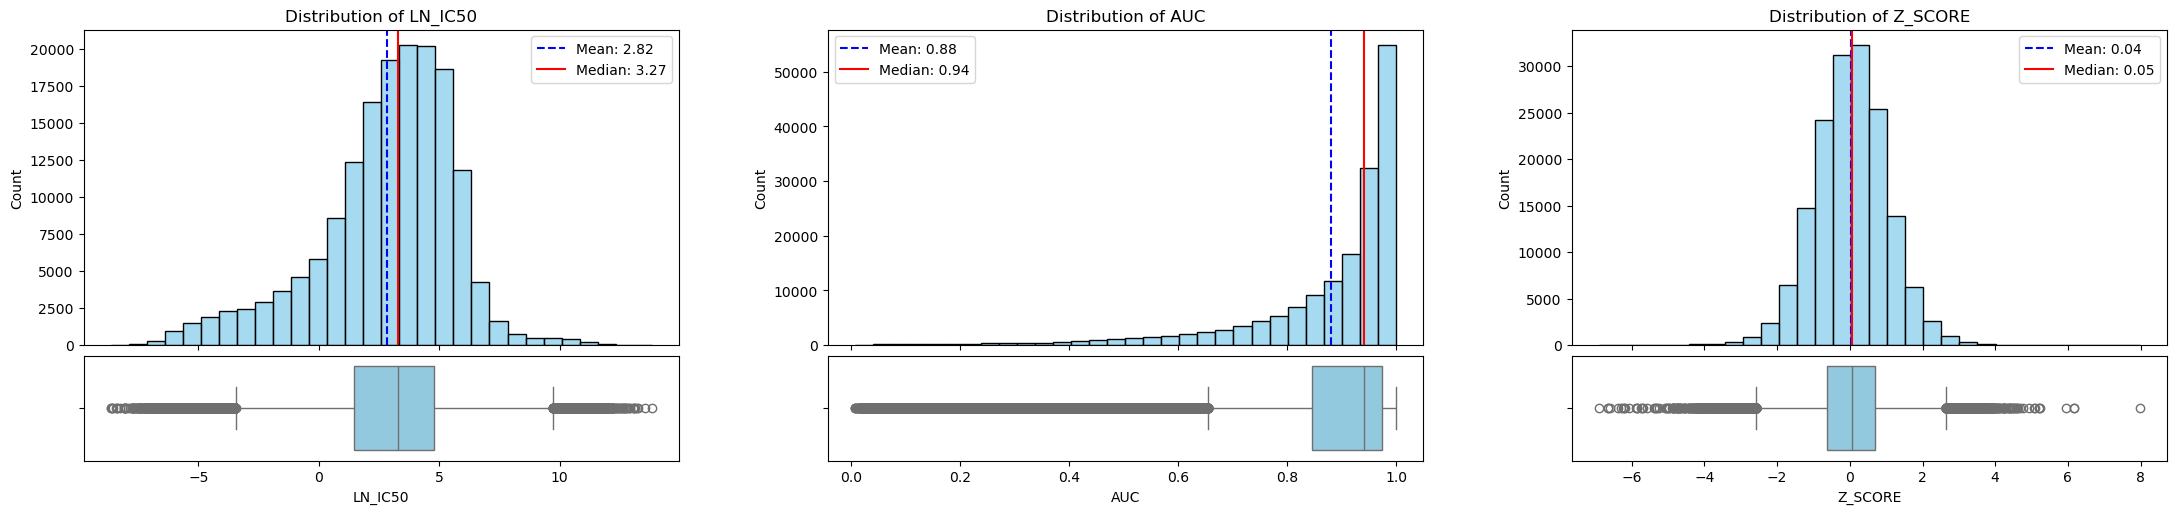

In [15]:
continuous = gdsc.select_dtypes('float').columns
plot_distribution(data=gdsc, columns=continuous)

### Discrete / Categorical Variables

In [16]:
identifiers = ["COSMIC_ID", "DRUG_ID", "DRUG_NAME", "CELL_LINE_NAME"] + ["TARGET"]
discretes = gdsc.select_dtypes(exclude='float').columns.difference(identifiers)

In [17]:
def plot_proportions(data: pd.DataFrame = None, columns: list[str] = None, show_pct=True, n_cols=3):
    if data is None or columns is None:
        print("Missing Dataframe or columns")
        return
    
    n = len(columns)
    n_cols = min(n_cols, n)
    n_rows = math.ceil(n / n_cols)
    
    figure, axes = plt.subplots(ncols=n_cols, nrows=n_rows, figsize=(SCREEN_W, SCREEN_H * 1.5), constrained_layout=True)
    
    axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]
    
    for i, column in enumerate(columns):
        value_counts = data[column].value_counts().sort_index()
        
        bars = axes[i].bar(
            value_counts.index.astype(str),
            value_counts.values,
            color="steelblue",
            edgecolor="black"
        )
        axes[i].set_title(column)
        axes[i].set_ylabel("Count")
        # axes[i].tick_params(axis="x", rotation=75)
        axes[i].set_xticks(range(len(value_counts)))
        axes[i].set_xticklabels(
            value_counts.index.astype(str),
            rotation=45,
            ha="right",
            fontsize=10
        )

        axes[i].set_ylim(0, value_counts.values.max() * 1.15)
        
        if show_pct:
            total = value_counts.sum()
            for bar, val in zip(bars, value_counts.values):
                pct = f"{(val / total) * 100:.1f}%"
                axes[i].text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height(),
                    pct,
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    rotation=0,
                )
     # Hide unused subplots
    for i in range(len(columns), len(axes)):
        axes[i].set_visible(False)

    # remove plt.tight_layout() if using constrained_layout=True above, it's more robust
    plt.show()  

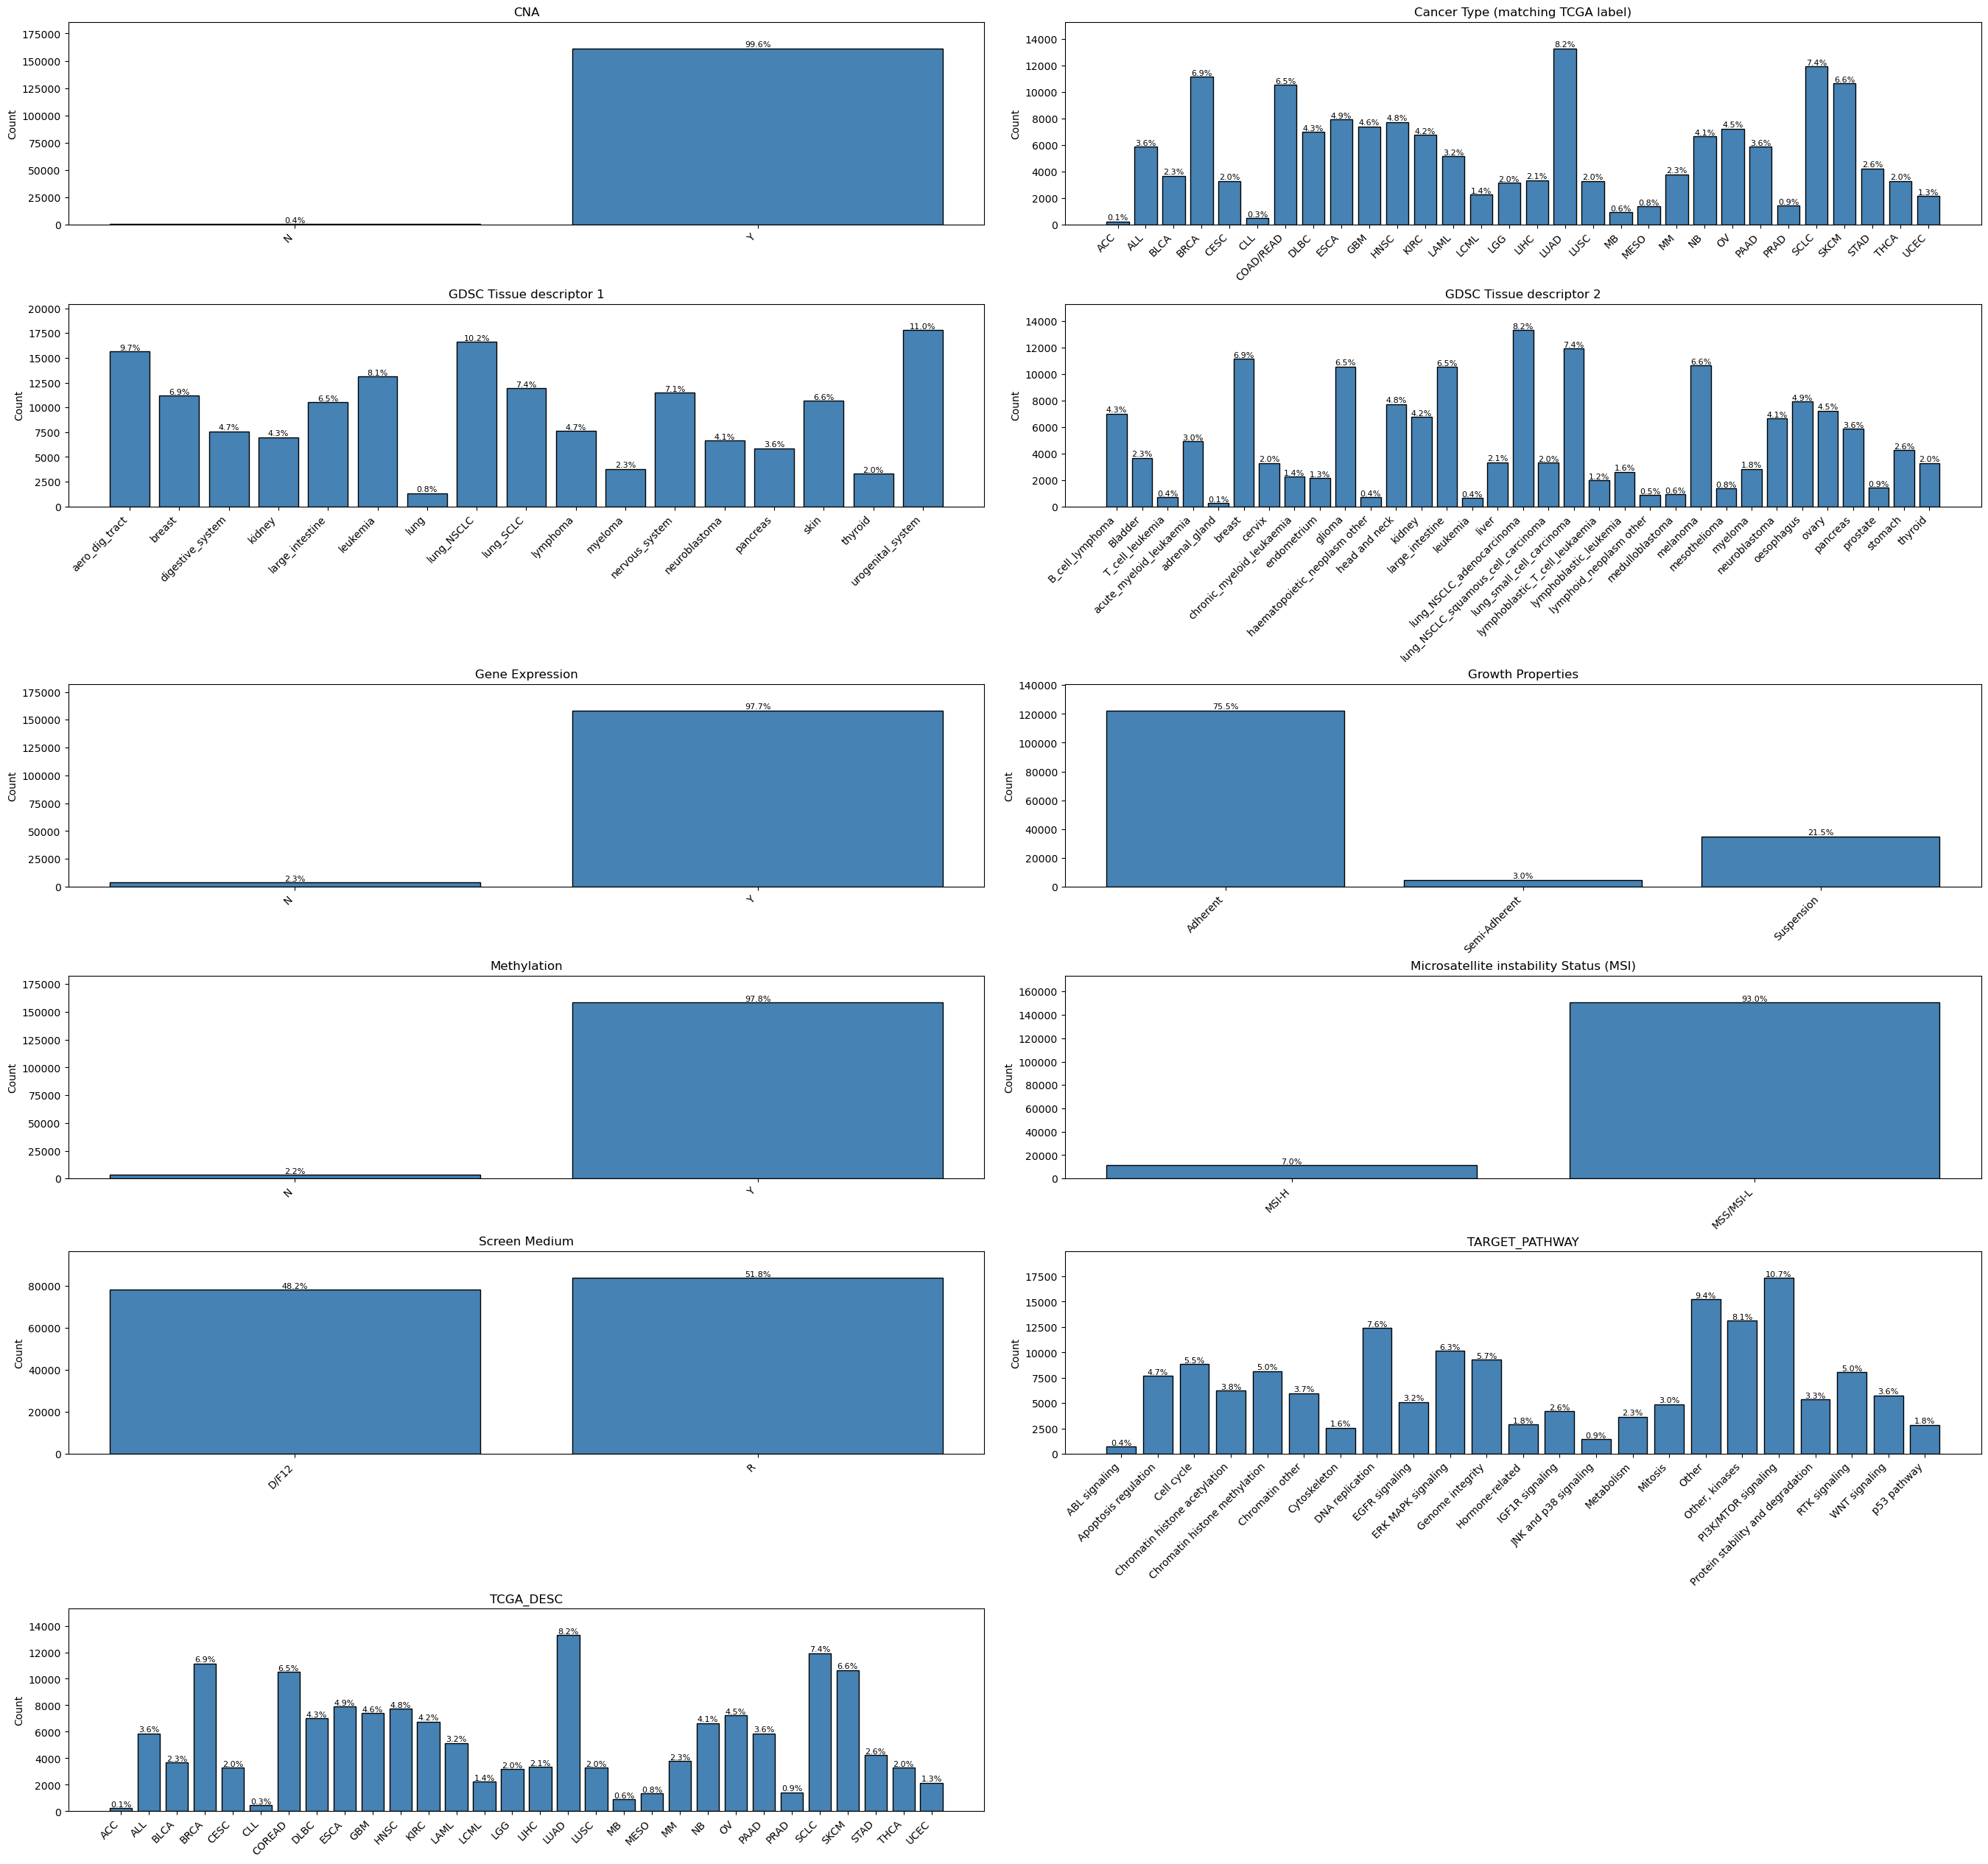

In [18]:
plot_proportions(data=gdsc, columns=discretes, n_cols=2)

## Multivariate Analysis


### Continuous

In [19]:
def plot_correlation(data: pd.DataFrame, columns: list, screen_w, screen_h, title="Correlation Matrix (Lower Triangle)"):
    """
    Plots correlation heatmap with the upper triangle masked.
    
    Parameters:
    - data: The dataframe containing the data.
    - columns: List of column names to include in the analysis. 
    - screen_w, screen_h: Figure dimensions.
    """
    
    if data is None or columns is None:
        print("❌ Missing dataframe or columns")
        return

    # 1. Calculate Correlation
    corr_matrix = data[columns].corr()

    # 2. Create a Mask for the Upper Triangle
    # np.triu returns the upper triangle of an array.
    # The mask should be True for the values you want to HIDE.
    # mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    mask = None

    # 3. Setup Plot 
    plt.figure(figsize=(screen_w, screen_h))
    plt.title(title)

    # 4. Render with Mask
    # Note: mask=mask argument hides the upper triangle
    sns.heatmap(corr_matrix, mask=mask, square=True, annot=True, cmap='coolwarm', center= 0, linewidths=0.5, fmt='.2f')
    
    plt.show()

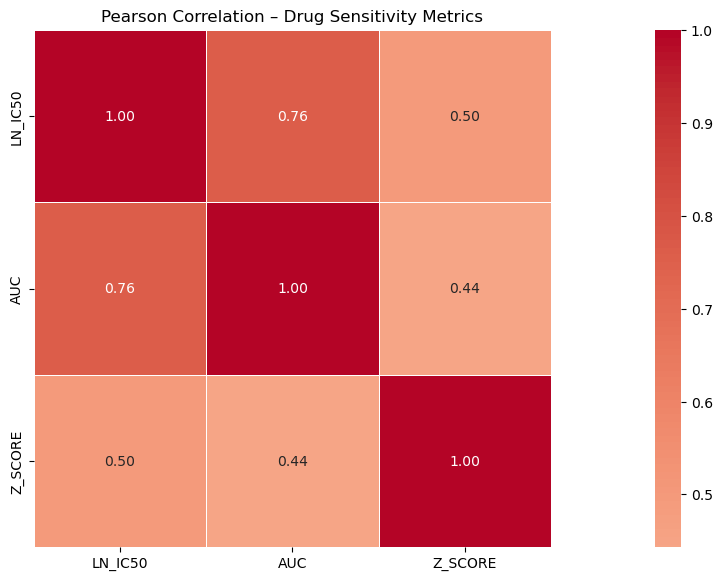

In [20]:
plot_correlation(data=gdsc, columns=continuous, screen_h=SCREEN_H / 2.5, screen_w=SCREEN_W, title="Pearson Correlation – Drug Sensitivity Metrics")

### Discretes - Continuous

In [21]:
drug_stats = (
    gdsc.groupby("DRUG_NAME")[["LN_IC50", "AUC", "Z_SCORE"]]
    .agg(["median", "std", "count"])
    .round(3)
)

drug_stats.columns = ["_".join(c) for c in drug_stats.columns]
drug_stats = drug_stats.reset_index()
drug_stats

,DRUG_NAME,LN_IC50_median,LN_IC50_std,LN_IC50_count,AUC_median,AUC_std,AUC_count,Z_SCORE_median,Z_SCORE_std,Z_SCORE_count
0,5-Fluorouracil,4.462,1.703,737,0.928,0.080,737,0.044,0.992,737
1,5-azacytidine,2.893,1.368,574,0.848,0.085,574,-0.069,0.985,574
2,A-366,4.927,1.016,574,0.971,0.019,574,0.054,0.991,574
3,ABT737,2.278,2.069,726,0.854,0.187,726,0.195,1.008,726
4,AGI-5198,4.712,0.915,727,0.969,0.018,727,0.013,1.012,727
...,...,...,...,...,...,...,...,...,...,...
241,YK-4-279,2.123,1.668,727,0.813,0.116,727,-0.073,1.011,727
242,ZM447439,2.538,1.704,715,0.872,0.102,715,-0.023,1.000,715
243,alpha-lipoic acid,7.705,1.002,572,0.976,0.017,572,0.057,1.038,572
244,ascorbate (vitamin C),10.450,1.288,567,0.977,0.034,567,0.156,1.005,567


## Drug Sensitivity Patterns

### Most Effective Drugs
We rank all drugs by **median LN_IC50 across all cell lines** and display the 15 most potent. These are drugs that inhibit 50 % of cell growth at the lowest concentration — candidates of high pharmacological interest.

Error bars (±1 SD) are shown to distinguish drugs that are universally potent from those that are potent only in a subset of cell lines.


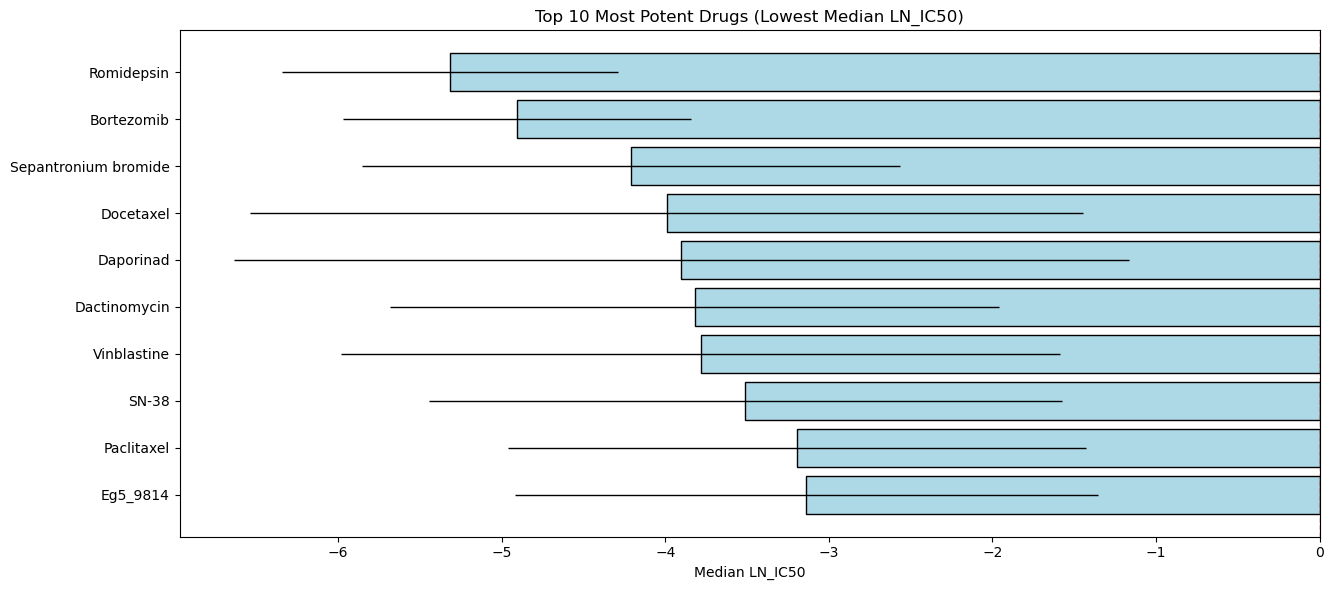

In [22]:
top_effective = drug_stats.nsmallest(10, "LN_IC50_median")

fig, ax = plt.subplots(figsize=(SCREEN_W * .5, 6))
bars = ax.barh(top_effective["DRUG_NAME"], top_effective["LN_IC50_median"],
               xerr=top_effective["LN_IC50_std"], color="lightblue",
               error_kw={"elinewidth": 1}, edgecolor="black")
ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Median LN_IC50")
ax.set_title("Top 10 Most Potent Drugs (Lowest Median LN_IC50)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

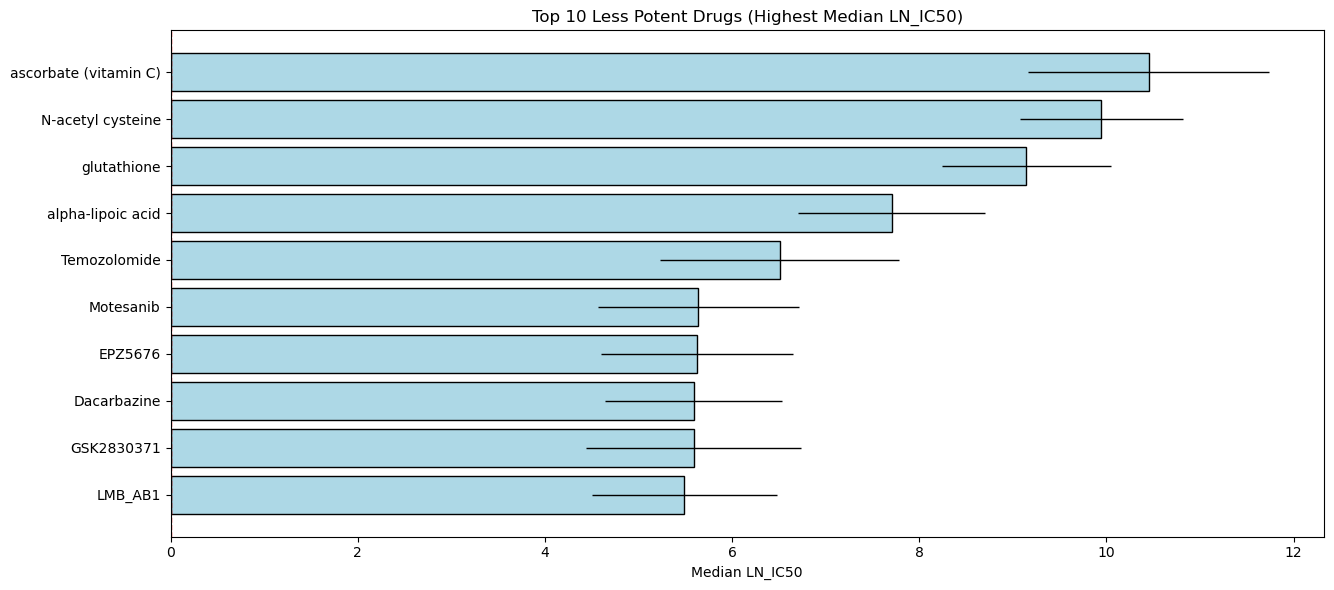

In [23]:
top_effective = drug_stats.nlargest(10, "LN_IC50_median")

fig, ax = plt.subplots(figsize=(SCREEN_W * .5, 6))

bars = ax.barh(top_effective["DRUG_NAME"], top_effective["LN_IC50_median"],
               xerr=top_effective["LN_IC50_std"], color="lightblue",
               error_kw={"elinewidth": 1}, edgecolor="black")

ax.axvline(0, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Median LN_IC50")
ax.set_title("Top 10 Less Potent Drugs (Highest Median LN_IC50)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Drugs with Highly Variable Response Across Cell Lines

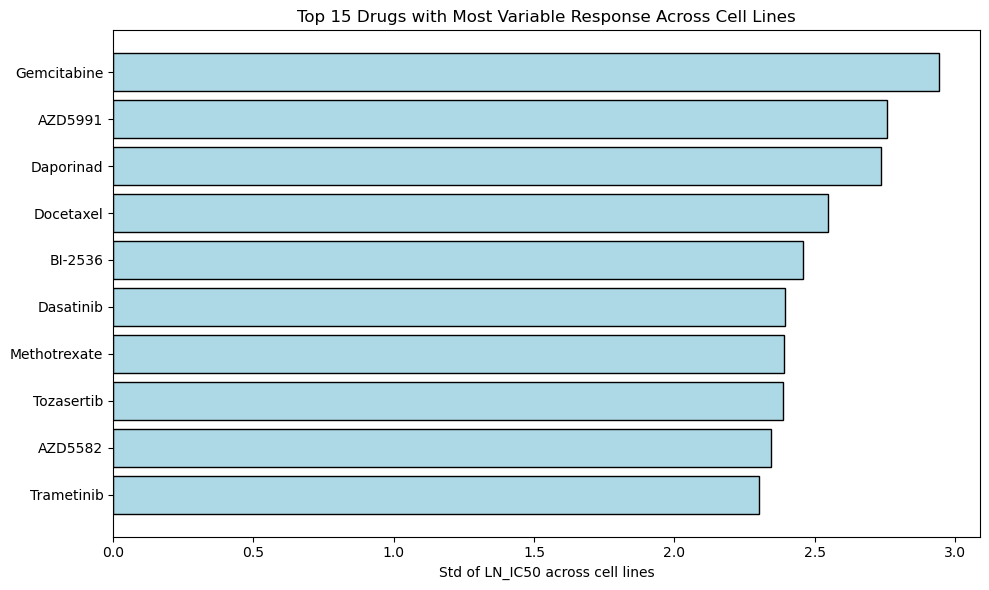

In [24]:
top_variable = drug_stats.nlargest(10, "LN_IC50_std")

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top_variable["DRUG_NAME"], top_variable["LN_IC50_std"],
        color="lightblue", edgecolor="black")

ax.set_xlabel("Std of LN_IC50 across cell lines")
ax.set_title("Top 15 Drugs with Most Variable Response Across Cell Lines")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Cancer Cell Line Analysis

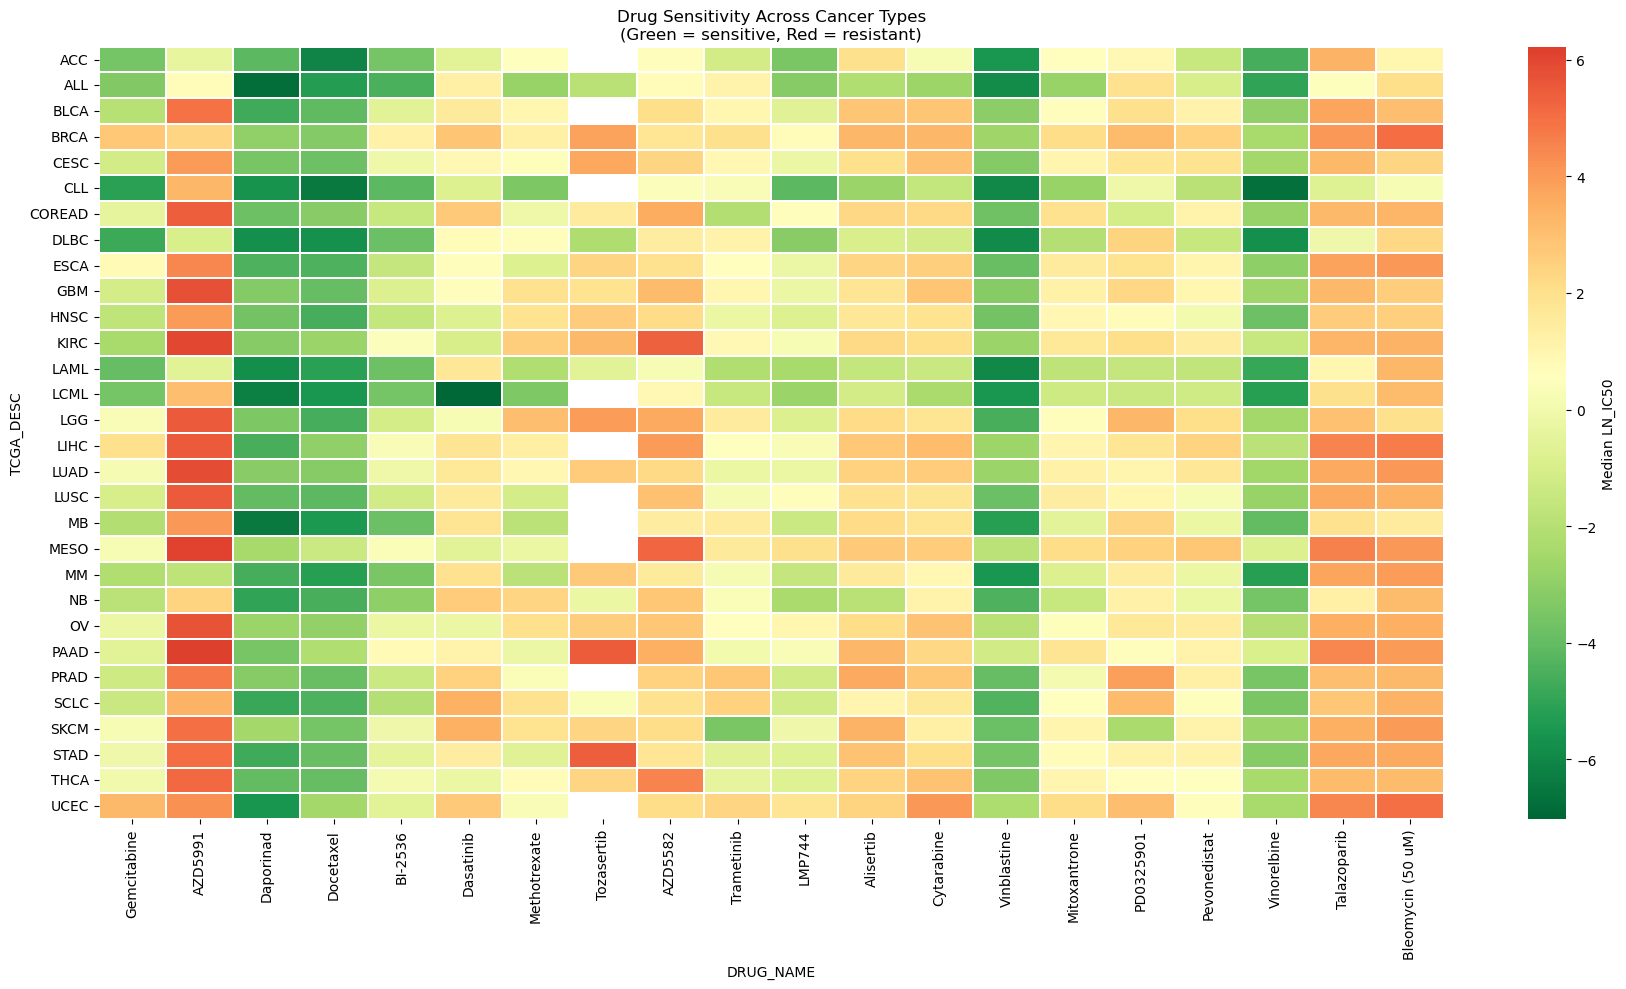

In [26]:
pivot = (
    gdsc.groupby(["TCGA_DESC", "DRUG_NAME"])["LN_IC50"]
    .median()
    .unstack("DRUG_NAME")
)

# Optional: reduce to top variable drugs (important!)
top_drugs = gdsc.groupby("DRUG_NAME")["LN_IC50"].std().nlargest(20).index
pivot = pivot[top_drugs]

fig, ax = plt.subplots(figsize=(18, 10))

sns.heatmap(
    pivot,
    cmap="RdYlGn_r",
    center=pivot.stack().median(),
    linewidths=0.2,
    cbar_kws={"label": "Median LN_IC50"},
    ax=ax
)

ax.set_title("Drug Sensitivity Across Cancer Types\n(Green = sensitive, Red = resistant)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

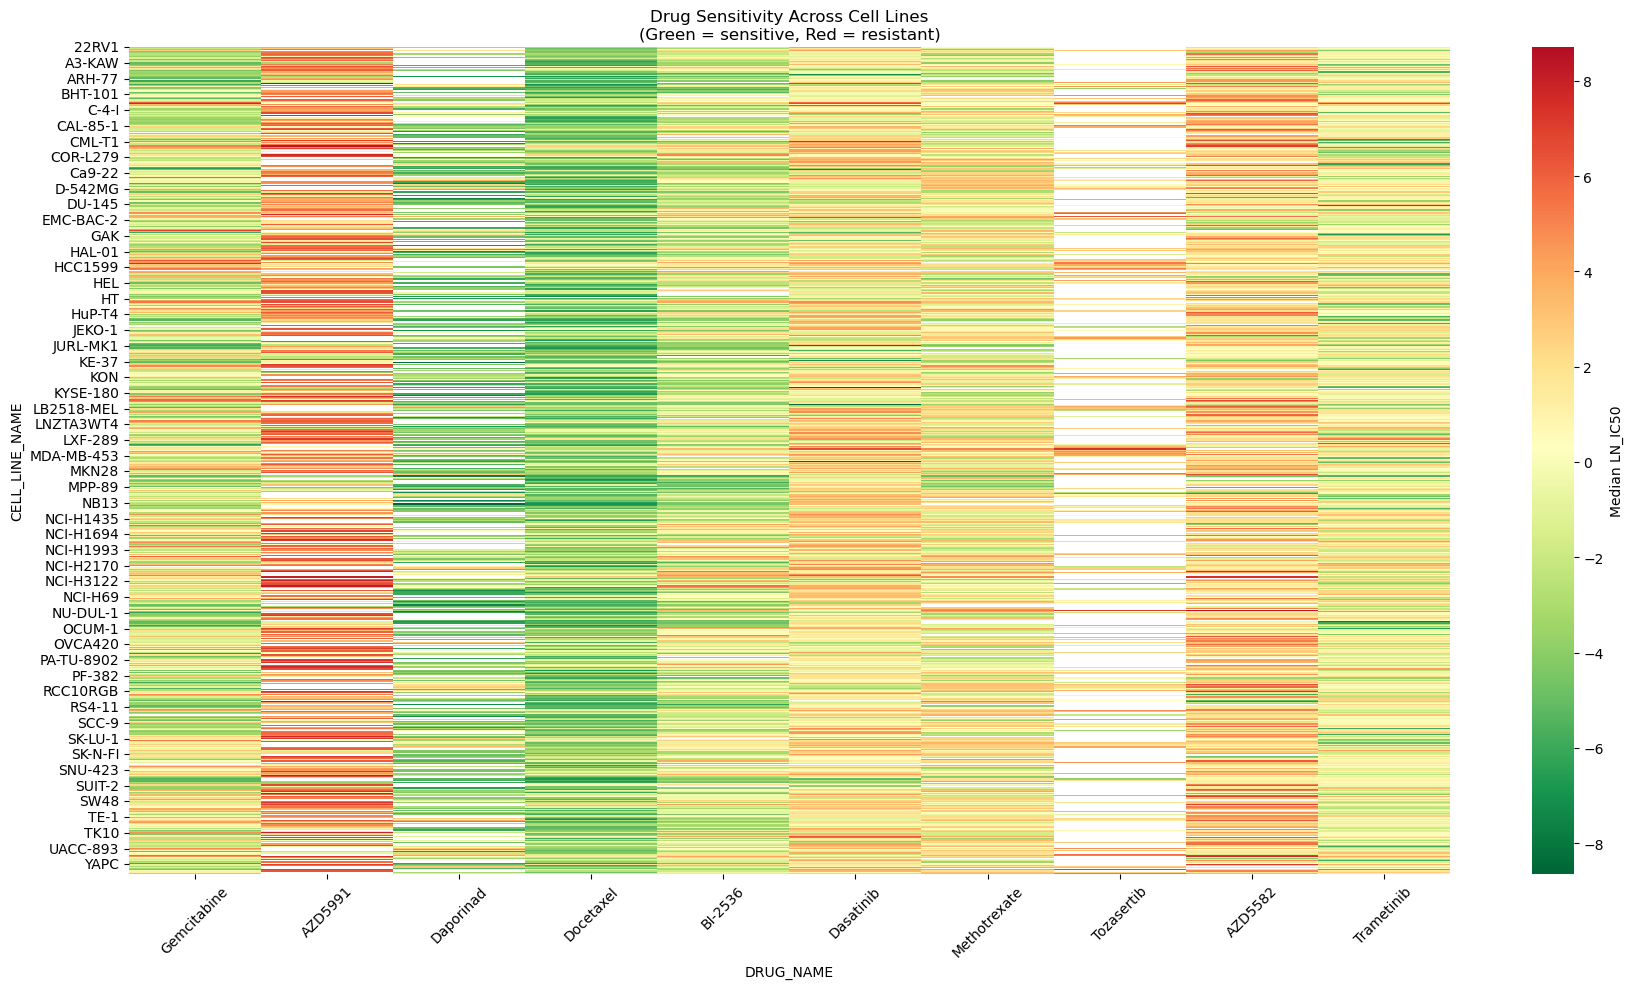

In [27]:
pivot = (
    gdsc.groupby(["CELL_LINE_NAME", "DRUG_NAME"])["LN_IC50"]
    .median()
    .unstack("DRUG_NAME")
)

# Optional: reduce to top variable drugs (important!)
top_drugs = gdsc.groupby("DRUG_NAME")["LN_IC50"].std().nlargest(10).index
pivot = pivot[top_drugs]

fig, ax = plt.subplots(figsize=(18, 10))

sns.heatmap(
    pivot,
    cmap="RdYlGn_r",
    center=pivot.stack().median(),
    linewidths=0,
    cbar_kws={"label": "Median LN_IC50"},
    ax=ax
)

ax.set_title("Drug Sensitivity Across Cell Lines\n(Green = sensitive, Red = resistant)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Genomic, Transcriptomic, and Epigenomic Influence on Drug Response

In [37]:
genomic_flags = ["CNA", "Gene Expression", "Methylation", "Microsatellite instability Status (MSI)"]
sensitivity_metrics = ["LN_IC50", "AUC", "Z_SCORE"]

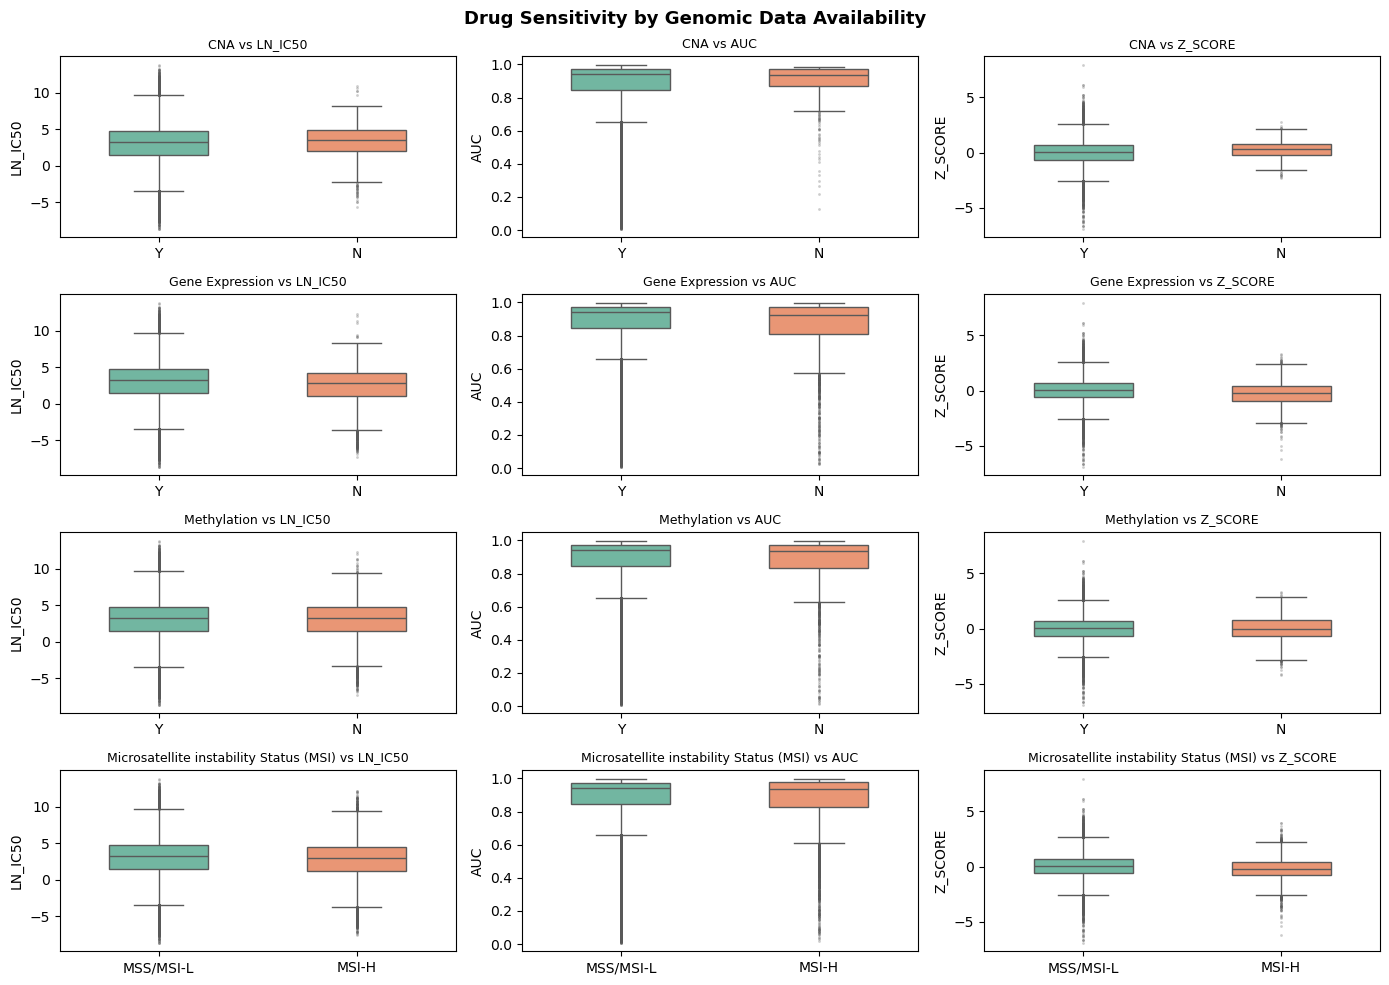

In [38]:
fig, axes = plt.subplots(len(genomic_flags), len(sensitivity_metrics), figsize=(14, 10))

for i, flag in enumerate(genomic_flags):
    for j, metric in enumerate(sensitivity_metrics):
        ax = axes[i][j]
        sns.boxplot(data=gdsc, x=flag, y=metric, hue=flag, palette="Set2",legend=False,
                    width=0.5, flierprops=dict(marker=".", markersize=2, alpha=0.3), ax=ax)
        ax.set_title(f"{flag} vs {metric}", fontsize=9)
        ax.set_xlabel("")

plt.suptitle("Drug Sensitivity by Genomic Data Availability", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("genomic_flags_vs_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
results = []

features = ["CNA", "Gene Expression", "Methylation"]

for drug in gdsc["DRUG_NAME"].unique():
    subset = gdsc[gdsc["DRUG_NAME"] == drug]

    drug_result = {"DRUG_NAME": drug}

    for feature in features:

        if subset[feature].nunique() < 2:
            drug_result[feature + "_p"] = None
            drug_result[feature + "_diff"] = None
            continue

        groups = subset[feature].unique()

        g1 = subset[subset[feature] == groups[0]]["LN_IC50"]
        g2 = subset[subset[feature] == groups[1]]["LN_IC50"]

        diff = g1.mean() - g2.mean()
        stat, p = ttest_ind(g1, g2)

        drug_result[feature + "_diff"] = diff
        drug_result[feature + "_p"] = p

    results.append(drug_result)

multi_feature_df = pd.DataFrame(results)
multi_feature_df.head()

,DRUG_NAME,CNA_diff,CNA_p,Gene Expression_diff,Gene Expression_p,Methylation_diff,Methylation_p
0,Camptothecin,0.481560,0.646084,0.320857,0.423930,0.152597,0.724269
1,Vinblastine,-0.795814,0.609865,-0.743470,0.735851,0.283926,0.734554
2,Cisplatin,-0.319934,0.802164,-2.172698,0.228258,-0.654884,0.307297
3,Cytarabine,-2.512486,0.111784,1.996983,0.371401,0.848055,0.317730
4,Docetaxel,-1.023860,0.369877,1.426749,0.010859,0.111533,0.831845
